In [76]:
from lightkurve import search_lightcurvefile

In [77]:
tic_id = "TIC 261136679"
lc_file = search_lightcurvefile(tic_id, mission="TESS").download()

C:\Users\DELL\AppData\Local\Temp\ipykernel_7932\4189938381.py:2: LightkurveDeprecationWarning: The search_lightcurvefile function is deprecated and may be removed in a future version.
        Use search_lightcurve() instead.
  lc_file = search_lightcurvefile(tic_id, mission="TESS").download()
f:\newworldbegins\Exoplanet\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 90 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [78]:
lc = lc_file.PDCSAP_FLUX
lc_clean = lc.remove_nans().normalize().flatten()


C:\Users\DELL\AppData\Local\Temp\ipykernel_7932\1046512266.py:1: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lc_file.PDCSAP_FLUX


In [79]:
import numpy as np
from scipy.interpolate import interp1d

def resample_lightcurve(lc, length=2000):
    x = lc.time.value
    y = lc.flux.value
    interp_fn = interp1d(x, y, kind='linear', fill_value="extrapolate")
    x_new = np.linspace(x.min(), x.max(), length)
    y_new = interp_fn(x_new)
    return np.column_stack((x_new, y_new))  # returns 2D array [time, flux]


resampled = resample_lightcurve(lc_clean)



In [80]:
import os

os.makedirs("data/processed", exist_ok=True)
np.save(f"data/processed/TIC_{tic_id.split()[1]}.npy", resampled)



In [81]:
import pandas as pd
np.save(f"data/processed/TIC_{tic_id.split()[1]}.npy", resampled)

df_labels = pd.DataFrame([{"TIC_ID": tic_id.split()[1], "label": 1}])
df_labels.to_csv("data/labels.csv", index=False)


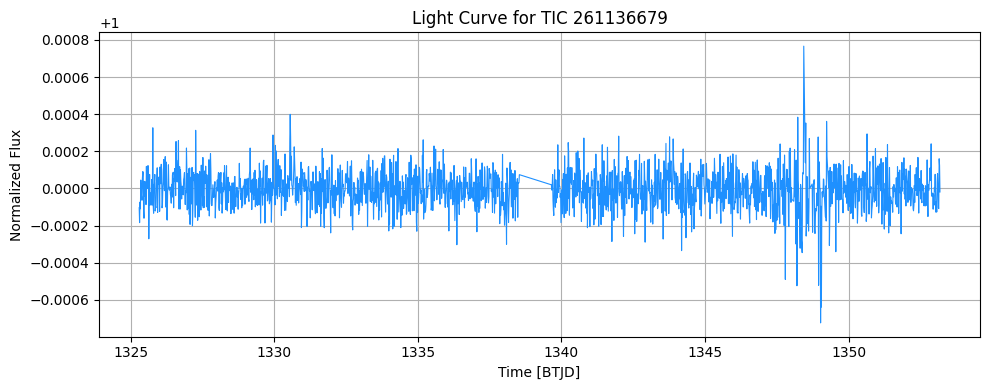

In [82]:
import matplotlib.pyplot as plt
resampled_time = resampled[:, 0]
resampled_flux = resampled[:, 1]

plt.figure(figsize=(10, 4))
plt.plot(resampled_time, resampled_flux, color="dodgerblue", linewidth=0.8)
plt.xlabel("Time [BTJD]")
plt.ylabel("Normalized Flux")
plt.title(f"Light Curve for TIC {tic_id.split()[1]}")
plt.grid(True)
plt.tight_layout()
plt.show()



In [83]:
from scipy.stats import zscore

flux_z = zscore(resampled_flux)
filtered_flux = resampled_flux[np.abs(flux_z) < 3]
filtered_time = resampled_time[np.abs(flux_z) < 3]


In [84]:
flux_normalized = (filtered_flux - np.mean(filtered_flux)) / np.std(filtered_flux)


In [85]:
import pandas as pd

df = pd.DataFrame({"time": filtered_time, "flux": flux_normalized})
df.interpolate(method="linear", inplace=True)
df.dropna(inplace=True)


In [86]:
from scipy.signal import savgol_filter

flux_smooth = savgol_filter(df["flux"], window_length=101, polyorder=2)


In [87]:
preprocessed = np.column_stack((df["time"].values, flux_smooth))
np.save(f"data/processed/TIC_{tic_id.split()[1]}_clean.npy", preprocessed)


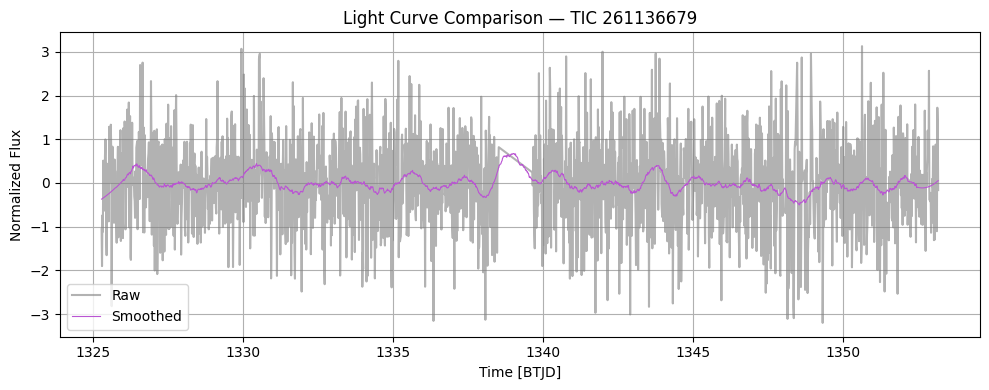

In [88]:
plt.figure(figsize=(10, 4))
plt.plot(filtered_time, df["flux"], color="gray", alpha=0.6, label="Raw")
plt.plot(filtered_time, flux_smooth, color="mediumorchid", linewidth=0.8, label="Smoothed")
plt.legend()
plt.xlabel("Time [BTJD]")
plt.ylabel("Normalized Flux")
plt.title(f"Light Curve Comparison — TIC {tic_id.split()[1]}")
plt.grid(True)
plt.tight_layout()
plt.show()





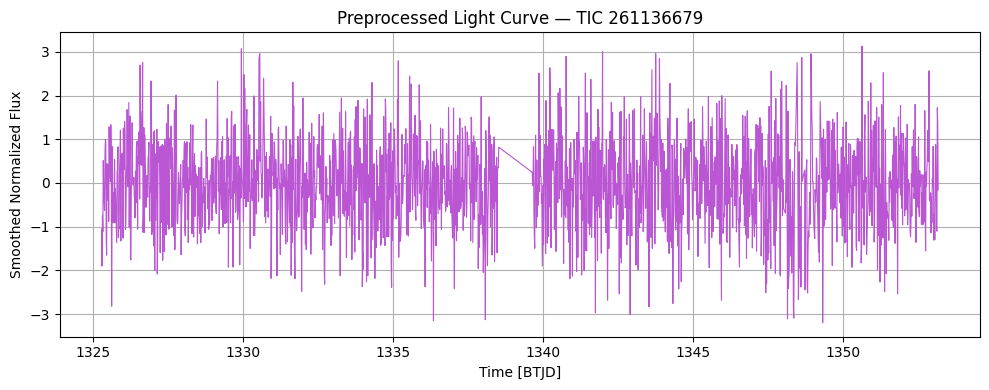

In [89]:
plt.figure(figsize=(10, 4))
plt.plot(df["time"], df["flux"], color="mediumorchid", linewidth=0.8)
plt.xlabel("Time [BTJD]")
plt.ylabel("Smoothed Normalized Flux")
plt.title(f"Preprocessed Light Curve — TIC {tic_id.split()[1]}")
plt.grid(True)
plt.tight_layout()
plt.show()



In [90]:
from astropy.timeseries import BoxLeastSquares
import numpy as np


In [91]:
time = np.array(filtered_time)
flux = np.array(flux_smooth)

# Remove any NaNs if present
mask = ~np.isnan(time) & ~np.isnan(flux)
time = time[mask]
flux = flux[mask]


In [92]:
model = BoxLeastSquares(time, flux)

# Define a reasonable period range (in days)
periods = np.linspace(0.5, 10, 10000)
durations = np.linspace(0.05, 0.2, 10)

results = model.autopower(durations, minimum_period=0.5, maximum_period=10)


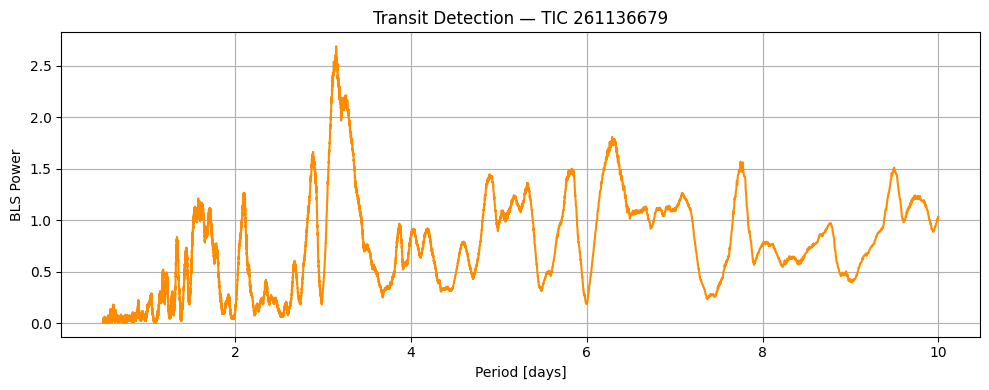

In [93]:
plt.figure(figsize=(10, 4))
plt.plot(results.period, results.power, color="darkorange")
plt.xlabel("Period [days]")
plt.ylabel("BLS Power")
plt.title(f"Transit Detection — TIC {tic_id.split()[1]}")
plt.grid(True)
plt.tight_layout()
plt.show()


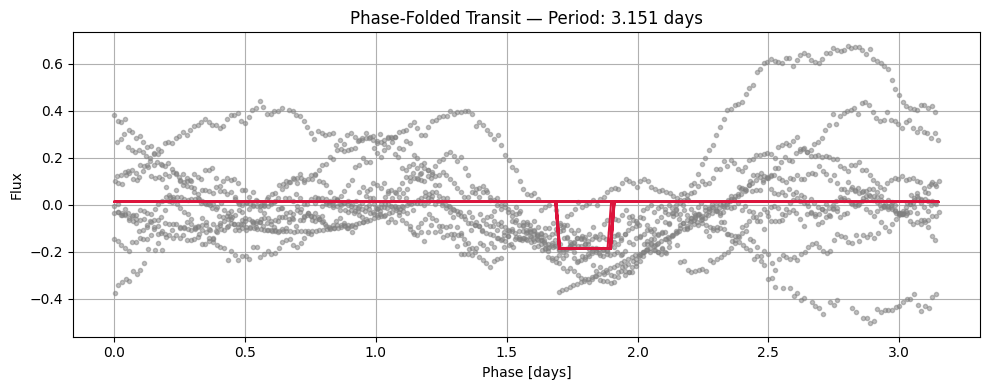

In [94]:
best_period = results.period[np.argmax(results.power)]
transit_model = model.model(time, best_period, results.duration[np.argmax(results.power)], results.transit_time[np.argmax(results.power)])

plt.figure(figsize=(10, 4))
plt.plot(time % best_period, flux, ".", color="gray", alpha=0.5)
plt.plot(time % best_period, transit_model, "-", color="crimson")
plt.xlabel("Phase [days]")
plt.ylabel("Flux")
plt.title(f"Phase-Folded Transit — Period: {best_period:.3f} days")
plt.grid(True)
plt.tight_layout()
plt.show()


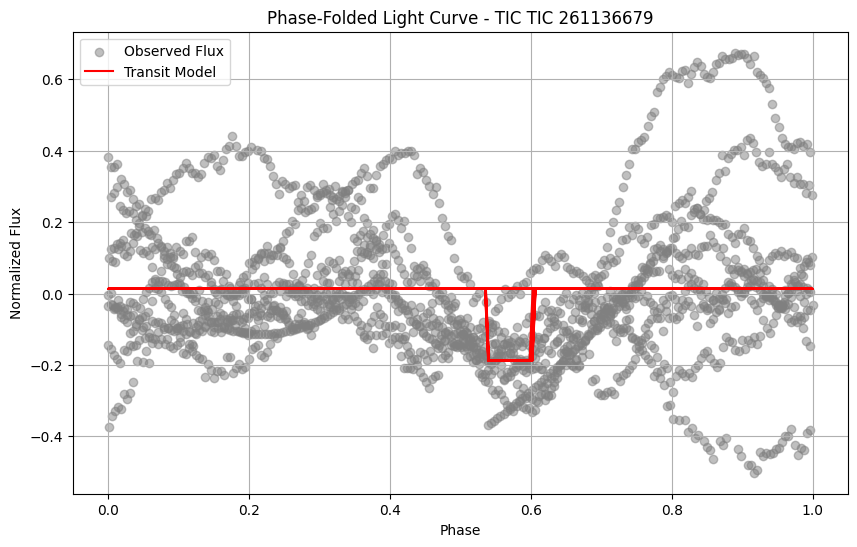

In [95]:
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares

# Phase-fold the time series
period = results.period[np.argmax(results.power)]
bls = BoxLeastSquares(time, flux)
model = bls.model(time, period, results.duration[np.argmax(results.power)], results.transit_time[np.argmax(results.power)])
phase = (time % period) / period

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(phase, flux, color='gray', alpha=0.5, label='Observed Flux')
plt.plot(phase, model, color='red', label='Transit Model')
plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title(f"Phase-Folded Light Curve - TIC {tic_id}")
plt.legend()
plt.grid(True)
plt.show()


In [96]:
best_index = np.argmax(results.power)

features = {
    "TIC_ID": tic_id.split()[1],
    "period": results.period[best_index],
    "duration": results.duration[best_index],
    "depth": results.depth[best_index],
    "transit_time": results.transit_time[best_index],
    "SNR": results.power[best_index],
    "mean_flux": np.mean(flux),
    "std_flux": np.std(flux),
    "label": 1  # if this is a known confirmed exoplanet
}


In [97]:
def extract_transit_features(results, tic_id):
    best = np.argmax(results.power)
    return {
        "TIC_ID": tic_id.split()[1],
        "period": results.period[best],
        "duration": results.duration[best],
        "depth": results.depth[best],
        "transit_time": results.transit_time[best],
        "SNR": results.power[best]
    }


In [98]:
import lightkurve as lk

# Download the light curve for the given TIC
search_result = lk.search_lightcurve("TIC 123456789", mission='TESS')
lc = search_result.download()

# Use PDCSAP flux for cleaner data
time = lc.time.value
flux = lc.PDCSAP_FLUX.value


f:\newworldbegins\Exoplanet\.venv\Lib\site-packages\lightkurve\search.py:420: LightkurveWarning: Warning: 5 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_7932\2327631832.py:9: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  flux = lc.PDCSAP_FLUX.value


KeyError: 'pdcsap_flux'